# Task 2: Inference & Evaluation — SciBERT

**Model:** `task2-m4pro-scibert-lr3e5-bs32-ep3-window_1`  
**Flow:** Score ALL candidates → rank → derive all metrics from rankings  
**Metrics:** MRR · Hits@1/3/5 · Precision · Recall · F1 · Confusion Matrix

In [3]:
import json
from pathlib import Path

MODEL_DIR   = "./outputs/models/task2-m4pro-scibert-lr3e5-bs32-ep3-window_1"
TEST_DIR    = "./data_outputs/task2/test"
RESULTS_DIR = "./outputs/results"
BATCH_SIZE  = 32   # inference batch size — chỉ ảnh hưởng tốc độ

# Đọc config từ lúc train — không cần chọn lại
RUN_NAME    = Path(MODEL_DIR).name
cfg         = json.loads(Path(f"./outputs/configs/{RUN_NAME}.json").read_text())
CONTEXT_MODE = cfg["context_mode"]
MAX_LENGTH   = cfg["max_length"]

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
print(f"✅ Model   : {RUN_NAME}")
print(f"   context : {CONTEXT_MODE}")
print(f"   max_len : {MAX_LENGTH}")

✅ Model   : task2-m4pro-scibert-lr3e5-bs32-ep3-window_1
   context : window_1
   max_len : 512


In [4]:
import json, re, csv, os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

Matplotlib is building the font cache; this may take a moment.
/Users/tathiyennhi/Documents/Works/automatic-citation-checking/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✅ Device: mps


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()
print(f"✅ Model loaded")

✅ Model loaded


In [6]:
def get_context(text, citation_id, mode="window_1"):
    if mode == "full":
        return text
    window = int(mode.split("_")[1])
    sentences = re.split(r"(?<=[.!?])\s+", text)
    target_idx = next((i for i, s in enumerate(sentences) if citation_id in s), -1)
    if target_idx == -1:
        return text
    start = max(0, target_idx - window)
    end   = min(len(sentences), target_idx + window + 1)
    return " ".join(sentences[start:end])


def load_ranking_groups(test_dir, context_mode):
    """Load ALL candidates per citation — no sampling."""
    label_files = sorted(Path(test_dir).glob("*.label"))
    total = len(label_files)
    print(f"📊 Loading {total:,} test files...")

    groups, skipped = [], 0
    for idx, lf in enumerate(label_files):
        if (idx + 1) % 500 == 0:
            print(f"  ⏳ {idx+1:,}/{total:,}")
        try:
            in_data    = json.loads(lf.with_suffix(".in").read_text())
            label_data = json.loads(lf.read_text())
        except Exception:
            skipped += 1; continue

        text        = in_data.get("text", "")
        candidates  = in_data.get("citation_candidates", [])
        bib_entries = in_data.get("bib_entries", {})
        correct_map = label_data.get("correct_citation", {})

        if not text or not candidates or not bib_entries or not correct_map:
            skipped += 1; continue

        for citation_id, correct_paper_id in correct_map.items():
            context = get_context(text, citation_id, mode=context_mode)
            cands = [
                {
                    "paper_id":   pid,
                    "text_b":     "{}.{}".format(
                        bib_entries[pid].get("title", ""),
                        bib_entries[pid].get("abstract", "")
                    ),
                    "is_correct": pid == correct_paper_id,
                }
                for pid in candidates if pid in bib_entries
            ]
            if cands:
                groups.append({"context": context, "candidates": cands})

    print(f"\n✅ {len(groups):,} ranking groups | skipped: {skipped}")
    return groups


groups = load_ranking_groups(TEST_DIR, CONTEXT_MODE)

📊 Loading 3,000 test files...
  ⏳ 500/3,000
  ⏳ 1,000/3,000
  ⏳ 1,500/3,000
  ⏳ 2,000/3,000
  ⏳ 2,500/3,000
  ⏳ 3,000/3,000

✅ 7,151 ranking groups | skipped: 0


In [7]:
# ── Inference: score ALL candidates, batch across groups ──
# Flatten everything into one big list, run in batches, then re-group.

texts_a, texts_b, group_ids = [], [], []
for gi, g in enumerate(groups):
    for c in g["candidates"]:
        texts_a.append(g["context"])
        texts_b.append(c["text_b"])
        group_ids.append(gi)

total_pairs = len(texts_a)
print(f"Total pairs to score: {total_pairs:,} ({len(groups):,} groups)")

all_scores = np.zeros(total_pairs, dtype=np.float32)

with torch.no_grad():
    for start in range(0, total_pairs, BATCH_SIZE):
        if start % (BATCH_SIZE * 100) == 0:
            print(f"  ⏳ {start:,}/{total_pairs:,}")
        end = min(start + BATCH_SIZE, total_pairs)
        enc = tokenizer(
            texts_a[start:end], texts_b[start:end],
            max_length=MAX_LENGTH, truncation=True,
            padding="max_length", return_tensors="pt"
        ).to(device)
        logits = model(**enc).logits
        scores = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_scores[start:end] = scores

# Re-attach scores to groups
score_cursor = 0
for gi, g in enumerate(groups):
    n = len(g["candidates"])
    g["scores"] = all_scores[score_cursor: score_cursor + n].tolist()
    score_cursor += n

print(f"\n✅ Scoring done")

Total pairs to score: 150,838 (7,151 groups)
  ⏳ 0/150,838
  ⏳ 3,200/150,838
  ⏳ 6,400/150,838
  ⏳ 9,600/150,838
  ⏳ 12,800/150,838
  ⏳ 16,000/150,838
  ⏳ 19,200/150,838
  ⏳ 22,400/150,838
  ⏳ 25,600/150,838
  ⏳ 28,800/150,838
  ⏳ 32,000/150,838
  ⏳ 35,200/150,838
  ⏳ 38,400/150,838
  ⏳ 41,600/150,838
  ⏳ 44,800/150,838
  ⏳ 48,000/150,838
  ⏳ 51,200/150,838
  ⏳ 54,400/150,838
  ⏳ 57,600/150,838
  ⏳ 60,800/150,838
  ⏳ 64,000/150,838
  ⏳ 67,200/150,838
  ⏳ 70,400/150,838
  ⏳ 73,600/150,838
  ⏳ 76,800/150,838
  ⏳ 80,000/150,838
  ⏳ 83,200/150,838
  ⏳ 86,400/150,838
  ⏳ 89,600/150,838
  ⏳ 92,800/150,838
  ⏳ 96,000/150,838
  ⏳ 99,200/150,838
  ⏳ 102,400/150,838
  ⏳ 105,600/150,838
  ⏳ 108,800/150,838
  ⏳ 112,000/150,838
  ⏳ 115,200/150,838
  ⏳ 118,400/150,838
  ⏳ 121,600/150,838
  ⏳ 124,800/150,838
  ⏳ 128,000/150,838
  ⏳ 131,200/150,838
  ⏳ 134,400/150,838
  ⏳ 137,600/150,838
  ⏳ 140,800/150,838
  ⏳ 144,000/150,838
  ⏳ 147,200/150,838
  ⏳ 150,400/150,838

✅ Scoring done


In [8]:
# ── Ranking metrics: MRR, Hits@K ──────────────────────────
reciprocal_ranks = []
hits = {1: 0, 3: 0, 5: 0}
ranks_list = []

for g in groups:
    ranked_idx = np.argsort(g["scores"])[::-1]
    correct_ranks = [
        rank + 1
        for rank, idx in enumerate(ranked_idx)
        if g["candidates"][idx]["is_correct"]
    ]
    if not correct_ranks:
        ranks_list.append(None)
        reciprocal_ranks.append(0.0)
        continue
    best = min(correct_ranks)
    ranks_list.append(best)
    reciprocal_ranks.append(1.0 / best)
    for k in hits:
        if best <= k:
            hits[k] += 1

n   = len(groups)
mrr = float(np.mean(reciprocal_ranks))

print("=" * 55)
print(f"🎯 RANKING METRICS | {RUN_NAME}")
print("=" * 55)
print(f"  Queries : {n:,}")
print(f"  MRR     : {mrr:.4f}")
for k in [1, 3, 5]:
    print(f"  Hits@{k}  : {hits[k]/n:.4f}  ({hits[k]:,}/{n:,})")
print("=" * 55)

🎯 RANKING METRICS | task2-m4pro-scibert-lr3e5-bs32-ep3-window_1
  Queries : 7,151
  MRR     : 0.5855
  Hits@1  : 0.4159  (2,974/7,151)
  Hits@3  : 0.6925  (4,952/7,151)
  Hits@5  : 0.8130  (5,814/7,151)


In [9]:
# ── Binary metrics derived from rankings ──────────────────
# Prediction = top-1 ranked candidate is_correct → TP/FP
# For every candidate: predicted positive if rank==1, else negative.

y_true, y_pred = [], []
for g in groups:
    ranked_idx = np.argsort(g["scores"])[::-1]
    top1_idx   = ranked_idx[0]
    for i, c in enumerate(g["candidates"]):
        y_true.append(int(c["is_correct"]))
        y_pred.append(1 if i == top1_idx else 0)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy  = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", pos_label=1, zero_division=0
)

print("=" * 55)
print(f"📊 BINARY METRICS (from top-1 prediction)")
print("=" * 55)
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1       : {f1:.4f}")
print("=" * 55)
print()
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"], digits=4))

📊 BINARY METRICS (from top-1 prediction)
  Accuracy : 0.9446
  Precision: 0.4159
  Recall   : 0.4159
  F1       : 0.4159

              precision    recall  f1-score   support

    Negative     0.9709    0.9709    0.9709    143687
    Positive     0.4159    0.4159    0.4159      7151

    accuracy                         0.9446    150838
   macro avg     0.6934    0.6934    0.6934    150838
weighted avg     0.9446    0.9446    0.9446    150838



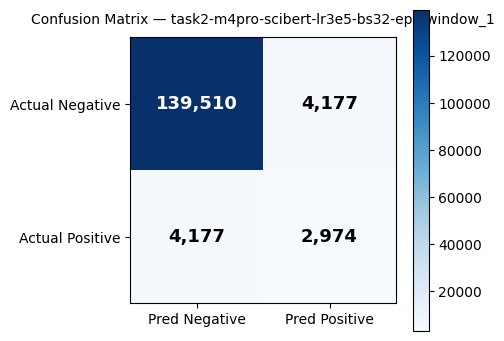

  TN=139,510  FP=4,177  FN=4,177  TP=2,974
✅ Saved: ./outputs/results/task2-m4pro-scibert-lr3e5-bs32-ep3-window_1_confusion_matrix.png


In [10]:
# ── Confusion matrix ───────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred Negative", "Pred Positive"], fontsize=10)
ax.set_yticklabels(["Actual Negative", "Actual Positive"], fontsize=10)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max() / 2 else "black",
                fontsize=13, fontweight="bold")
ax.set_title(f"Confusion Matrix — {RUN_NAME}", fontsize=10, pad=10)
plt.tight_layout()
cm_path = f"{RESULTS_DIR}/{RUN_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"✅ Saved: {cm_path}")

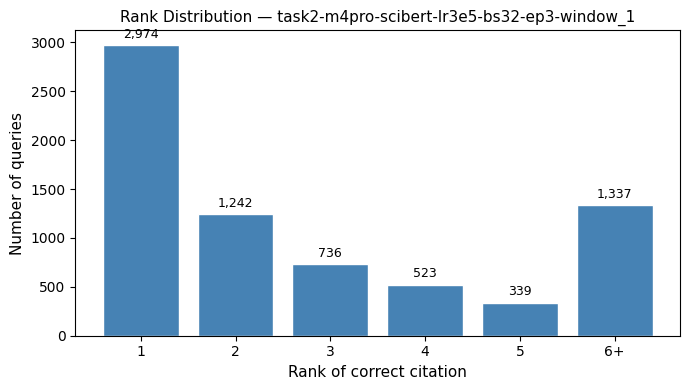

✅ Saved: ./outputs/results/task2-m4pro-scibert-lr3e5-bs32-ep3-window_1_rank_distribution.png


In [11]:
# ── Rank distribution ──────────────────────────────────────
valid_ranks = [r for r in ranks_list if r is not None]
rank_counts = {}
for r in valid_ranks:
    key = min(r, 6)
    rank_counts[key] = rank_counts.get(key, 0) + 1

labels_r = [str(k) if k < 6 else "6+" for k in sorted(rank_counts)]
values_r = [rank_counts[k] for k in sorted(rank_counts)]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels_r, values_r, color="steelblue", edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,}" for v in values_r], padding=3, fontsize=9)
ax.set_xlabel("Rank of correct citation", fontsize=11)
ax.set_ylabel("Number of queries", fontsize=11)
ax.set_title(f"Rank Distribution — {RUN_NAME}", fontsize=11)
plt.tight_layout()
rd_path = f"{RESULTS_DIR}/{RUN_NAME}_rank_distribution.png"
plt.savefig(rd_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {rd_path}")

In [12]:
# ── Leaderboard: all ablation runs ────────────────────────
summary_path = f"{RESULTS_DIR}/ablation_summary.csv"
if os.path.exists(summary_path):
    df = pd.read_csv(summary_path)
    cols = ["run_name", "model", "learning_rate", "effective_batch_size",
            "context_mode", "eval_f1", "eval_accuracy", "eval_precision", "eval_recall"]
    df = df[cols].sort_values("eval_f1", ascending=False).reset_index(drop=True)
    df.index += 1
    for col in ["eval_f1", "eval_accuracy", "eval_precision", "eval_recall"]:
        df[col] = df[col].map("{:.4f}".format)
    print("📊 VAL LEADERBOARD (all ablation runs)")
    print("=" * 100)
    print(df.to_string())
    print("=" * 100)

📊 VAL LEADERBOARD (all ablation runs)
                                      run_name                             model  learning_rate  effective_batch_size context_mode eval_f1 eval_accuracy eval_precision eval_recall
1  task2-m4pro-scibert-lr3e5-bs32-ep3-window_1  allenai/scibert_scivocab_uncased        0.00003                    32     window_1  0.6163        0.8223         0.6803      0.5633
2     task2-m4pro-bert-lr3e5-bs32-ep3-window_1                 bert-base-uncased        0.00003                    32     window_1  0.5890        0.8137         0.6678      0.5268
3     task2-m4pro-bert-lr3e5-bs64-ep3-window_1                 bert-base-uncased        0.00003                    64     window_1  0.5859        0.8131         0.6679      0.5219
4     task2-m4pro-bert-lr5e5-bs32-ep3-window_1                 bert-base-uncased        0.00005                    32     window_1  0.5759        0.8112         0.6682      0.5059
5     task2-m4pro-bert-lr3e5-bs16-ep3-window_1                

In [13]:
# ── Save results ───────────────────────────────────────────
test_results = {
    "run_name":          RUN_NAME,
    "n_queries":         n,
    "n_total_pairs":     int(total_pairs),
    # ranking
    "mrr":               round(mrr, 4),
    "hits_at_1":         round(hits[1] / n, 4),
    "hits_at_3":         round(hits[3] / n, 4),
    "hits_at_5":         round(hits[5] / n, 4),
    # binary (from top-1)
    "accuracy":          round(float(accuracy),  4),
    "precision":         round(float(precision), 4),
    "recall":            round(float(recall),    4),
    "f1":                round(float(f1),        4),
    "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
}

json_path = f"{RESULTS_DIR}/{RUN_NAME}_test_results.json"
with open(json_path, "w") as f:
    json.dump(test_results, f, indent=2)
print(f"✅ JSON: {json_path}")

csv_path = f"{RESULTS_DIR}/test_summary.csv"
write_hdr = not os.path.exists(csv_path)
with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=test_results.keys())
    if write_hdr:
        writer.writeheader()
    writer.writerow(test_results)
print(f"✅ CSV: {csv_path}")

print()
print("=" * 55)
print(f"🎉 FINAL TEST RESULTS | {RUN_NAME}")
print("=" * 55)
print(f"  MRR      : {test_results['mrr']:.4f}")
print(f"  Hits@1   : {test_results['hits_at_1']:.4f}")
print(f"  Hits@3   : {test_results['hits_at_3']:.4f}")
print(f"  Hits@5   : {test_results['hits_at_5']:.4f}")
print(f"  F1       : {test_results['f1']:.4f}")
print(f"  Accuracy : {test_results['accuracy']:.4f}")
print(f"  Precision: {test_results['precision']:.4f}")
print(f"  Recall   : {test_results['recall']:.4f}")
print("=" * 55)

✅ JSON: ./outputs/results/task2-m4pro-scibert-lr3e5-bs32-ep3-window_1_test_results.json
✅ CSV: ./outputs/results/test_summary.csv

🎉 FINAL TEST RESULTS | task2-m4pro-scibert-lr3e5-bs32-ep3-window_1
  MRR      : 0.5855
  Hits@1   : 0.4159
  Hits@3   : 0.6925
  Hits@5   : 0.8130
  F1       : 0.4159
  Accuracy : 0.9446
  Precision: 0.4159
  Recall   : 0.4159
